# Gigs Senior Data Analyst Challenge

Welcome to the Gigs data analyst take-home challenge! This notebook will help you get started with analyzing our connectivity usage data.

## About the Data

You'll be working with three main datasets:
- **Usage Data**: Detailed usage per subscription period (~100K+ records)
- **Plan Events**: Plan configuration and pricing history
- **Projects**: Project metadata

## Setup Instructions

Run the cells below to set up your environment and load the data into DuckDB.

In [6]:
# Import required libraries
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [7]:
# Load JupySQL extension and configure
%load_ext sql

# Configure JupySQL for better output
%config SqlMagic.autopandas = True
%config SqlMagic.feedback = False
%config SqlMagic.displaycon = False

print("✅ JupySQL configured!")

The sql extension is already loaded. To reload it, use:
  %reload_ext sql
✅ JupySQL configured!


In [9]:
# Connect to DuckDB
conn = duckdb.connect('gigs-analytics.db')
%sql conn --alias duckdb

print("✅ Connected to DuckDB database: gigs-analytics.db")

✅ Connected to DuckDB database: gigs-analytics.db


In [10]:
%%sql
-- Load data into DuckDB tables
CREATE
OR REPLACE TABLE usage_data AS
SELECT
  *
FROM
  'data/usage_by_subscription_period.csv';

CREATE
OR REPLACE TABLE plan_events AS
SELECT
  *
FROM
  'data/plan_change_events.csv';

CREATE
OR REPLACE TABLE projects AS
SELECT
  *
FROM
  'data/projects.csv';

,Count
0,3


In [11]:
%%sql
-- Verify data loading
SELECT
  'usage_data' AS table_name,
  COUNT(*) AS row_count,
  COUNT(DISTINCT subscription_id) AS unique_subscriptions,
  COUNT(DISTINCT plan_id) AS unique_plans,
  COUNT(DISTINCT project_id__hashed) AS unique_projects
FROM
  usage_data
UNION ALL
SELECT
  'plan_events' AS table_name,
  COUNT(*) AS row_count,
  NULL,
  COUNT(DISTINCT plan_id) AS unique_plans,
  NULL
FROM
  plan_events
UNION ALL
SELECT
  'projects' AS table_name,
  COUNT(*) AS row_count,
  NULL,
  NULL,
  COUNT(DISTINCT project_id__hashed) AS unique_projects
FROM
  projects;

,table_name,row_count,unique_subscriptions,unique_plans,unique_projects
0,usage_data,53565,8457,12,3
1,plan_events,209,<NA>,36,<NA>
2,projects,3,<NA>,<NA>,3


## Your Analysis Starts Here!

Now you have everything set up. Use the cells below to start your analysis.

### Tips:
- Use `%%sql` for multi-line SQL queries
- Use `%sql variable_name <<` to store results in a Python variable
- Combine SQL with Python/Pandas for advanced analysis
- Feel free to use any visualisation library you feel comfortable with

In [12]:
%%sql
--data validations about plans and projects
--1. validate that all plans or projects in usage_data exist in the respective tables
-- => looks correct, as no results are returned
SELECT
  usage_data.*
FROM
  usage_data
  LEFT JOIN plan_events USING (plan_id)
WHERE
  plan_events.plan_id IS NULL
UNION ALL
SELECT
  usage_data.*
FROM
  usage_data
  LEFT JOIN plan_events USING (project_id__hashed)
WHERE
  plan_events.project_id__hashed IS NULL
UNION ALL
SELECT
  usage_data.*
FROM
  usage_data
  LEFT JOIN projects USING (project_id__hashed)
WHERE
  projects.project_id__hashed IS NULL;

--2. check if any plans have had changes that might have affected usage behaviour or retention
/* I will not write the queries, but I checked and confirmed that none of these happened
- change in price
- change in allowance
- change of provider
- change of validity unit duration
The impact of such events would have been interesting.
Overall I noticed in the plan_events table that across all events, no significant characteristic of any plan ever changed.
*/
--3. Another finding: all plans are used at most by one project (no plan ID with duplicate project ID values)
--This would have allowed to compare the patterns of the same plan in 2 different projects.
SELECT
  plan_id,
  COUNT(DISTINCT project_id__hashed) AS nr_projects
FROM
  usage_data
GROUP BY
  1;

,plan_id,nr_projects
0,pln_c2e73083cdcd7349ed576eea5f06,1
1,pln_b109c69e95246b6d535b9cc9174f,1
2,pln_1d3f49d61a672755efc1865c4d9a,1
3,pln_3547586bf1a44e88d28081a6a456,1
4,pln_e4a7120c0bc0b1a583d931cf5815,1
5,pln_af7b4a30086929d37e7f4eb3daed,1
6,pln_c5b25fc1ad1cfcaf90a87b7e086a,1
7,pln_0a3b55b9abb575b023c07e617b49,1
8,pln_430cdc0fcb816e47e1ce1fc05b0c,1
9,pln_588c59e59103c836fb97c0352a47,1


In [166]:
%%sql
--data usage validations
/*
There are some weird cases where I would like to dive deeper. There is no time for this with the current time limit
for this exercise, but I would check whether the raw data is broken or our dbt models have any bugs,
and potentially also request a back end engineer to take a look if the raw data looks wrong.
My preference would be to exclude these subscriptions completely while the issues are being investigated. I won't do it here, 
but preferrably I would create in dbt a separate model with the problematic subscriptions and exclude them completely from the
refined table (and not specifically from this analysis).


Bug 1:
Some subscriptions do not have a consistent row number of the subscription_period_number.
*/
SELECT
  subscription_id,
  COUNT(*) c1,
  COUNT(DISTINCT subscription_period_number) c2
FROM
  usage_data
GROUP BY
  1
HAVING
  c1 != c2;

/*
Bug 2: 
Some subscription periods last longer than they are supposed to.
Normally plans either last 1 month or 30 days. So logically, the date diff between the start and end date should be 28-31 days,
or less in case of early cancellation.
There are some records where the date diff is higher than this and sometimes even higher than 2 months. 
*/
SELECT
  subscription_id,
  subscription_period_number,
  subscription_period_start,
  subscription_period_end,
  subscription_period_end - subscription_period_start AS datediff
FROM
  usage_data
WHERE
  subscription_period_end - subscription_period_start > 31;

--for example this subscription showcases both bugs: period 4 is missing, period 7 exists twice, and the last period lasts 55 days
SELECT
  subscription_id,
  subscription_period_number,
  subscription_period_start,
  subscription_period_end,
  subscription_period_end - subscription_period_start AS datediff
FROM
  usage_data
WHERE
  subscription_id = 'sub_ec1b59fd9ff4aa6bcd2664334eb7'
ORDER BY
  1,
  2,
  3;

,subscription_id,subscription_period_number,subscription_period_start,subscription_period_end,datediff
0,sub_ec1b59fd9ff4aa6bcd2664334eb7,1,2024-06-30,2024-07-31,31
1,sub_ec1b59fd9ff4aa6bcd2664334eb7,2,2024-07-31,2024-08-29,29
2,sub_ec1b59fd9ff4aa6bcd2664334eb7,3,2024-08-29,2024-09-30,32
3,sub_ec1b59fd9ff4aa6bcd2664334eb7,5,2024-10-30,2024-11-30,31
4,sub_ec1b59fd9ff4aa6bcd2664334eb7,7,2024-12-30,2025-01-31,32
5,sub_ec1b59fd9ff4aa6bcd2664334eb7,7,2024-12-30,2025-02-23,55


In [170]:
%%sql

--Data usage

--unlimited on average consume 9.6GB, 5GB consume 1.7GB, 1GB consume 366MB

/*interestingly there are some subscriptions with zero allowance (in the plan pln_c2e73083cdcd7349ed576eea5f06)
who consume on average 3.8GB and can go up to 80GB in a month, presumably paying for this usage, 
which is potentially an opportunity to upsell an unlimited data plan to them (sacrificing revenue to increase retention)
*/
with plan_features as (
select distinct plan_id, is_unlimited_data, data_allowance_mb
from plan_events
)
select case
        when is_unlimited_data then 'unlimited'
        else concat('limit: ', cast((data_allowance_mb/1000) as text))
      end as allowance
    , avg(cumulative_data_usage_megabyte) as avg_data_used
    , max(cumulative_data_usage_megabyte) as max_data_used
from usage_data
left join plan_features
  using (plan_id)
group by 1
order by 1



,allowance,avg_data_used,max_data_used
0,limit: 0.0,3766.828288,80762.446848
1,limit: 1.0,365.934925,110371.431424
2,limit: 5.0,1694.664483,250785.320960
3,unlimited,9633.045948,282946.536448


In [177]:
%%sql
CREATE or replace TABLE usage_kpis as 
with plan_features as (
select distinct plan_id, is_unlimited_data, data_allowance_mb
from plan_events
)
select case
        when is_unlimited_data then 'unlimited'
        else concat('limit: ', cast((data_allowance_mb/1000) as text))
      end as allowance
    , avg(cumulative_data_usage_megabyte) as avg_data_used
    , max(cumulative_data_usage_megabyte) as max_data_used
from usage_data
left join plan_features
  using (plan_id)
group by 1
order by 1
;


,Count
0,4


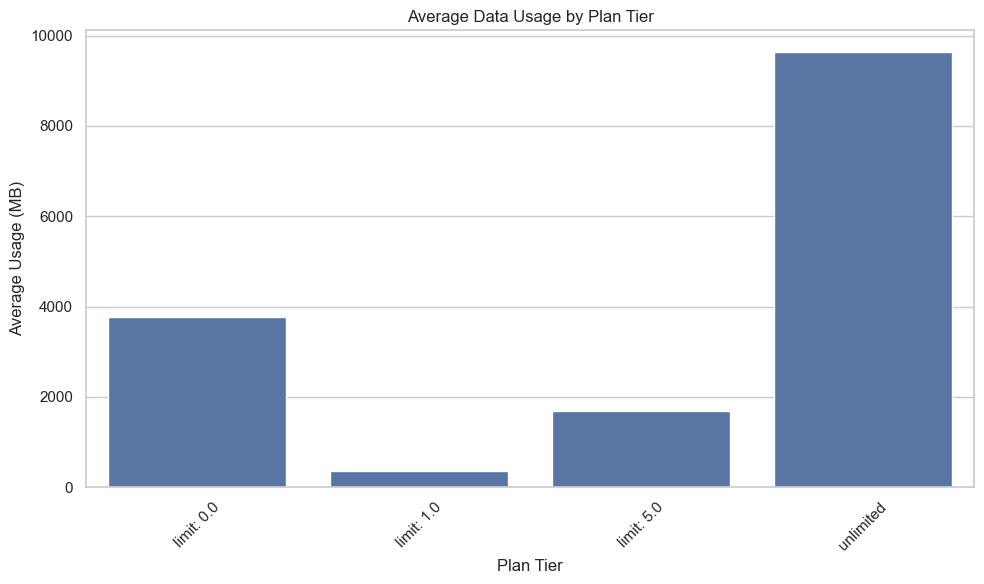

In [200]:
result = %sql SELECT * FROM usage_kpis
;

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.barplot(data=result, x='allowance', y='avg_data_used')
plt.title('Average Data Usage by Plan Tier')
plt.xlabel('Plan Tier')
plt.ylabel('Average Usage (MB)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()